In [4]:
# Google Drive'ı bağla
from google.colab import drive
drive.mount('/content/drive')

# Çalışma dizinini değiştir
import os
os.chdir('/content/drive/MyDrive/BitcoinProject')
print("✅ Çalışma dizini:", os.getcwd())
print("📁 Dosyalar:", os.listdir())
print("📁 data klasörü:", os.listdir('data'))

Mounted at /content/drive
✅ Çalışma dizini: /content/drive/MyDrive/BitcoinProject
📁 Dosyalar: ['data', 'IBRAHIM_YANAC_22040101043_MacroMinds_AdvancedModels.ipynb']
📁 data klasörü: ['merged_with_lags.csv']


# 🚀 MacroMinds - Advanced Bitcoin Price Prediction Models

**Author:** İbrahim Yanac  
**Student ID:** 22040101043  
**Project:** Bitcoin Price Prediction with Advanced ML Models

---

## 📋 İçerik
1. Dataset Yükleme ve Ön İşleme
2. Target ve Feature Ayrımı
3. Zaman Serisi Split
4. Model-1: Random Forest (Advanced + Tuning)
5. Model-2: MLP Regressor (Neural Network)
6. Metrik Hesaplama
7. Grafik Çizimi (Real vs Pred)
8. Model Kaydetme
9. Sonuçları CSV'ye Yazma
10. En İyi Model Seçimi

## 1️⃣ Gerekli Kütüphanelerin Yüklenmesi

In [5]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from datetime import datetime

# Scikit-learn modülleri
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Uyarıları kapat
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


## 2️⃣ Klasörlerin Oluşturulması

In [6]:
# Gerekli klasörleri oluştur
os.makedirs('plots_advanced_ibrahim', exist_ok=True)
os.makedirs('models_advanced_ibrahim', exist_ok=True)

print("📁 Klasörler oluşturuldu:")
print("   - plots_advanced_ibrahim/")
print("   - models_advanced_ibrahim/")

📁 Klasörler oluşturuldu:
   - plots_advanced_ibrahim/
   - models_advanced_ibrahim/


## 3️⃣ Dataset'i Yükle

In [7]:
# CSV'yi oku
df = pd.read_csv('data/merged_with_lags.csv')

# Date'i datetime yap
df['Date'] = pd.to_datetime(df['Date'])

# Tarihe göre sırala
df = df.sort_values('Date').reset_index(drop=True)

print(f"📊 Dataset Bilgileri:")
print(f"   - Toplam satır: {len(df):,}")
print(f"   - Toplam kolon: {len(df.columns)}")
print(f"   - Tarih aralığı: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\n📅 İlk 5 satır:")
df.head()

📊 Dataset Bilgileri:
   - Toplam satır: 3,338
   - Toplam kolon: 117
   - Tarih aralığı: 2015-09-15 → 2024-11-03

📅 İlk 5 satır:


,Date,FEDFUNDS,ECBDFR,CPI,UNRATE,IVV,GSPC,EURUSDX,DXY,PAYEMS,...,GCF_lag7,GCF_lag30,GCF_lag90,GCF_lag365,GDP_lag1,GDP_lag3,GDP_lag7,GDP_lag30,GDP_lag90,GDP_lag365
0,2015-09-15,0.14,-0.2,23.511166,5.0,167.513916,3.239860e+09,0.0,991.849976,142275.0,...,138.0,908.0,168.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
1,2015-09-16,0.14,-0.2,23.466616,5.0,169.016098,3.630680e+09,0.0,982.549988,142275.0,...,150.0,399.0,130.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
2,2015-09-17,0.14,-0.2,23.573530,5.0,168.588120,4.183790e+09,0.0,991.849976,142275.0,...,56.0,475.0,142.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
3,2015-09-18,0.14,-0.2,23.573530,5.0,165.776855,6.021240e+09,0.0,1039.979980,142275.0,...,81.0,348.0,142.0,5.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
4,2015-09-19,0.14,-0.2,23.573530,5.0,165.776855,6.021240e+09,0.0,1039.979980,142275.0,...,81.0,409.0,142.0,4.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228


In [8]:
# ✔️ Çıktıyı kontrol et
print("🔍 Dataset Kontrolü:")
print(f"\n📌 Kolon isimleri ({len(df.columns)} adet):")
print(df.columns.tolist())

print(f"\n📌 Veri tipleri:")
print(df.dtypes.value_counts())

print(f"\n📌 Eksik değer sayısı:")
print(f"   Toplam: {df.isnull().sum().sum()}")

🔍 Dataset Kontrolü:

📌 Kolon isimleri (117 adet):
['Date', 'FEDFUNDS', 'ECBDFR', 'CPI', 'UNRATE', 'IVV', 'GSPC', 'EURUSDX', 'DXY', 'PAYEMS', 'WALCL', 'ZQF', 'VIX', 'BTC-USD', 'STLFSI2', 'GCF', 'GDP', 'Target_1d', 'Target_7d', 'Target_30d', 'Target_365d', 'FEDFUNDS_lag1', 'FEDFUNDS_lag3', 'FEDFUNDS_lag7', 'FEDFUNDS_lag30', 'FEDFUNDS_lag90', 'FEDFUNDS_lag365', 'ECBDFR_lag1', 'ECBDFR_lag3', 'ECBDFR_lag7', 'ECBDFR_lag30', 'ECBDFR_lag90', 'ECBDFR_lag365', 'CPI_lag1', 'CPI_lag3', 'CPI_lag7', 'CPI_lag30', 'CPI_lag90', 'CPI_lag365', 'UNRATE_lag1', 'UNRATE_lag3', 'UNRATE_lag7', 'UNRATE_lag30', 'UNRATE_lag90', 'UNRATE_lag365', 'IVV_lag1', 'IVV_lag3', 'IVV_lag7', 'IVV_lag30', 'IVV_lag90', 'IVV_lag365', 'GSPC_lag1', 'GSPC_lag3', 'GSPC_lag7', 'GSPC_lag30', 'GSPC_lag90', 'GSPC_lag365', 'EURUSDX_lag1', 'EURUSDX_lag3', 'EURUSDX_lag7', 'EURUSDX_lag30', 'EURUSDX_lag90', 'EURUSDX_lag365', 'DXY_lag1', 'DXY_lag3', 'DXY_lag7', 'DXY_lag30', 'DXY_lag90', 'DXY_lag365', 'PAYEMS_lag1', 'PAYEMS_lag3', 'PAYEMS_lag

## 4️⃣ Target ve Feature Ayrımı

In [9]:
# Target kolonları
targets = ['Target_1d', 'Target_7d', 'Target_30d', 'Target_365d']

print("🎯 Target Kolonları:")
for t in targets:
    print(f"   - {t}")

# Feature set oluştur
# Date ve Target'ları çıkar, sadece numeric kolonları al
exclude_cols = ['Date'] + targets
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Sadece numeric kolonları al
X = df[feature_cols].select_dtypes(include=[np.number]).copy()

print(f"\n📊 Feature Sayısı: {len(X.columns)}")
print(f"\n📌 Feature Listesi:")
print(X.columns.tolist())

🎯 Target Kolonları:
   - Target_1d
   - Target_7d
   - Target_30d
   - Target_365d

📊 Feature Sayısı: 112

📌 Feature Listesi:
['FEDFUNDS', 'ECBDFR', 'CPI', 'UNRATE', 'IVV', 'GSPC', 'EURUSDX', 'DXY', 'PAYEMS', 'WALCL', 'ZQF', 'VIX', 'BTC-USD', 'STLFSI2', 'GCF', 'GDP', 'FEDFUNDS_lag1', 'FEDFUNDS_lag3', 'FEDFUNDS_lag7', 'FEDFUNDS_lag30', 'FEDFUNDS_lag90', 'FEDFUNDS_lag365', 'ECBDFR_lag1', 'ECBDFR_lag3', 'ECBDFR_lag7', 'ECBDFR_lag30', 'ECBDFR_lag90', 'ECBDFR_lag365', 'CPI_lag1', 'CPI_lag3', 'CPI_lag7', 'CPI_lag30', 'CPI_lag90', 'CPI_lag365', 'UNRATE_lag1', 'UNRATE_lag3', 'UNRATE_lag7', 'UNRATE_lag30', 'UNRATE_lag90', 'UNRATE_lag365', 'IVV_lag1', 'IVV_lag3', 'IVV_lag7', 'IVV_lag30', 'IVV_lag90', 'IVV_lag365', 'GSPC_lag1', 'GSPC_lag3', 'GSPC_lag7', 'GSPC_lag30', 'GSPC_lag90', 'GSPC_lag365', 'EURUSDX_lag1', 'EURUSDX_lag3', 'EURUSDX_lag7', 'EURUSDX_lag30', 'EURUSDX_lag90', 'EURUSDX_lag365', 'DXY_lag1', 'DXY_lag3', 'DXY_lag7', 'DXY_lag30', 'DXY_lag90', 'DXY_lag365', 'PAYEMS_lag1', 'PAYEMS_lag3'

In [10]:
# NaN ve inf temizle (ffill + bfill)
print("🧹 Veri Temizleme:")
print(f"   - Temizlemeden önce NaN sayısı: {X.isnull().sum().sum()}")

# Önce inf değerleri NaN yap
X = X.replace([np.inf, -np.inf], np.nan)

# ffill (forward fill) + bfill (backward fill)
X = X.ffill().bfill()

print(f"   - Temizlemeden sonra NaN sayısı: {X.isnull().sum().sum()}")

# Eğer hala NaN varsa 0 ile doldur
if X.isnull().sum().sum() > 0:
    X = X.fillna(0)
    print("   - Kalan NaN'lar 0 ile dolduruldu.")

print("\n✅ Veri temizleme tamamlandı!")

🧹 Veri Temizleme:
   - Temizlemeden önce NaN sayısı: 0
   - Temizlemeden sonra NaN sayısı: 0

✅ Veri temizleme tamamlandı!


## 5️⃣ Zaman Serisi Split

In [11]:
# ASLA RANDOM DEĞİL - Zaman bazlı split
# %80 train, %20 test

split_ratio = 0.80
split_index = int(len(df) * split_ratio)

print(f"📊 Zaman Serisi Split:")
print(f"   - Toplam veri: {len(df):,} satır")
print(f"   - Split oranı: {split_ratio*100:.0f}% train / {(1-split_ratio)*100:.0f}% test")
print(f"   - Split index: {split_index}")
print(f"\n   - Train seti: {split_index:,} satır ({df['Date'].iloc[0].date()} → {df['Date'].iloc[split_index-1].date()})")
print(f"   - Test seti: {len(df) - split_index:,} satır ({df['Date'].iloc[split_index].date()} → {df['Date'].iloc[-1].date()})")

# Feature split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Test tarihleri (grafik için)
test_dates = df['Date'].iloc[split_index:].reset_index(drop=True)

print(f"\n✅ Split tamamlandı!")
print(f"   - X_train shape: {X_train.shape}")
print(f"   - X_test shape: {X_test.shape}")

📊 Zaman Serisi Split:
   - Toplam veri: 3,338 satır
   - Split oranı: 80% train / 20% test
   - Split index: 2670

   - Train seti: 2,670 satır (2015-09-15 → 2023-01-05)
   - Test seti: 668 satır (2023-01-06 → 2024-11-03)

✅ Split tamamlandı!
   - X_train shape: (2670, 112)
   - X_test shape: (668, 112)


## 6️⃣ Model-1: Random Forest (Advanced + Tuning)

In [12]:
# Random Forest için parametre alanı
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

print("🌲 Random Forest Parametre Alanı:")
for param, values in rf_param_grid.items():
    print(f"   - {param}: {values}")

🌲 Random Forest Parametre Alanı:
   - n_estimators: [50, 100, 200, 300]
   - max_depth: [5, 10, 15, 20, None]
   - min_samples_split: [2, 5, 10, 20]
   - min_samples_leaf: [1, 2, 4, 8]
   - max_features: ['sqrt', 'log2', None]


In [13]:
# Sonuçları saklayacak dictionary
rf_results = {}
rf_models = {}
rf_predictions = {}
rf_best_params = {}

print("🌲 Random Forest Eğitimi Başlıyor...\n")
print("="*60)

for target in targets:
    print(f"\n🎯 Target: {target}")
    print("-"*40)

    # Target split
    y = df[target].copy()
    y = y.ffill().bfill().fillna(0)  # NaN temizle
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # RandomizedSearchCV ile tuning
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

    # TimeSeriesSplit kullan (zaman serisi için uygun)
    tscv = TimeSeriesSplit(n_splits=3)

    rf_search = RandomizedSearchCV(
        rf_base,
        rf_param_grid,
        n_iter=20,  # 20 farklı kombinasyon dene
        cv=tscv,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    print("   ⏳ RandomizedSearchCV çalışıyor...")
    rf_search.fit(X_train, y_train)

    # En iyi model
    best_rf = rf_search.best_estimator_
    rf_best_params[target] = rf_search.best_params_

    print(f"   ✅ En iyi parametreler: {rf_search.best_params_}")

    # Tahmin yap
    y_pred = best_rf.predict(X_test)

    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

    print(f"   📊 Metrikler:")
    print(f"      - RMSE: {rmse:.4f}")
    print(f"      - MAE: {mae:.4f}")
    print(f"      - R²: {r2:.4f}")
    print(f"      - MAPE: {mape:.2f}%")

    # Sonuçları sakla
    rf_results[target] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }
    rf_models[target] = best_rf
    rf_predictions[target] = y_pred

print("\n" + "="*60)
print("✅ Random Forest eğitimi tamamlandı!")

🌲 Random Forest Eğitimi Başlıyor...


🎯 Target: Target_1d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}
   📊 Metrikler:
      - RMSE: 2399.4691
      - MAE: 1664.6692
      - R²: 0.9808
      - MAPE: 3.62%

🎯 Target: Target_7d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': None}
   📊 Metrikler:
      - RMSE: 21219.7688
      - MAE: 16945.2492
      - R²: -0.4862
      - MAPE: 33.06%

🎯 Target: Target_30d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
   📊 Metrikler:
      - RMSE: 26274.4251
      -

## 7️⃣ Model-2: MLP Regressor (Neural Network)

In [14]:
# MLP için özellikleri ölçeklendir (ŞART!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("🔧 StandardScaler uygulandı!")
print(f"   - X_train_scaled shape: {X_train_scaled.shape}")
print(f"   - X_test_scaled shape: {X_test_scaled.shape}")

🔧 StandardScaler uygulandı!
   - X_train_scaled shape: (2670, 112)
   - X_test_scaled shape: (668, 112)


In [15]:
# MLP için parametre alanı
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32), (256, 128)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000, 1500]
}

print("🧠 MLP Parametre Alanı:")
for param, values in mlp_param_grid.items():
    print(f"   - {param}: {values}")

🧠 MLP Parametre Alanı:
   - hidden_layer_sizes: [(64,), (128,), (64, 32), (128, 64), (128, 64, 32), (256, 128)]
   - alpha: [0.0001, 0.001, 0.01, 0.1]
   - learning_rate: ['constant', 'adaptive']
   - max_iter: [500, 1000, 1500]


In [16]:
# Sonuçları saklayacak dictionary
mlp_results = {}
mlp_models = {}
mlp_predictions = {}
mlp_best_params = {}

print("🧠 MLP Regressor Eğitimi Başlıyor...\n")
print("="*60)

for target in targets:
    print(f"\n🎯 Target: {target}")
    print("-"*40)

    # Target split
    y = df[target].copy()
    y = y.ffill().bfill().fillna(0)  # NaN temizle
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # RandomizedSearchCV ile tuning
    mlp_base = MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.1)

    # TimeSeriesSplit kullan
    tscv = TimeSeriesSplit(n_splits=3)

    mlp_search = RandomizedSearchCV(
        mlp_base,
        mlp_param_grid,
        n_iter=15,  # 15 farklı kombinasyon dene
        cv=tscv,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    print("   ⏳ RandomizedSearchCV çalışıyor...")
    mlp_search.fit(X_train_scaled, y_train)

    # En iyi model
    best_mlp = mlp_search.best_estimator_
    mlp_best_params[target] = mlp_search.best_params_

    print(f"   ✅ En iyi parametreler: {mlp_search.best_params_}")

    # Tahmin yap
    y_pred = best_mlp.predict(X_test_scaled)

    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

    print(f"   📊 Metrikler:")
    print(f"      - RMSE: {rmse:.4f}")
    print(f"      - MAE: {mae:.4f}")
    print(f"      - R²: {r2:.4f}")
    print(f"      - MAPE: {mape:.2f}%")

    # Sonuçları sakla
    mlp_results[target] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }
    mlp_models[target] = best_mlp
    mlp_predictions[target] = y_pred

print("\n" + "="*60)
print("✅ MLP Regressor eğitimi tamamlandı!")

🧠 MLP Regressor Eğitimi Başlıyor...


🎯 Target: Target_1d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'max_iter': 500, 'learning_rate': 'constant', 'hidden_layer_sizes': (256, 128), 'alpha': 0.001}
   📊 Metrikler:
      - RMSE: 30556.5492
      - MAE: 24367.1462
      - R²: -2.1116
      - MAPE: 46.82%

🎯 Target: Target_7d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'max_iter': 500, 'learning_rate': 'constant', 'hidden_layer_sizes': (256, 128), 'alpha': 0.001}
   📊 Metrikler:
      - RMSE: 32934.7413
      - MAE: 26380.1857
      - R²: -2.5801
      - MAPE: 50.29%

🎯 Target: Target_30d
----------------------------------------
   ⏳ RandomizedSearchCV çalışıyor...
   ✅ En iyi parametreler: {'max_iter': 500, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128,), 'alpha': 0.1}
   📊 Metrikler:
      - RMSE: 32745.0091
      - MAE: 24551.4153
      - R²: -1.9352
     

## 8️⃣ Metrikleri Özetle

In [17]:
# Tüm metrikleri bir DataFrame'de topla
all_results = []

# Random Forest sonuçları
for target in targets:
    all_results.append({
        'Target': target,
        'Model': 'RandomForest',
        'RMSE': rf_results[target]['RMSE'],
        'MAE': rf_results[target]['MAE'],
        'R2': rf_results[target]['R2'],
        'MAPE_%': rf_results[target]['MAPE'],
        'Num_Features': len(X.columns),
        'Best_Params': str(rf_best_params[target])
    })

# MLP sonuçları
for target in targets:
    all_results.append({
        'Target': target,
        'Model': 'MLPRegressor',
        'RMSE': mlp_results[target]['RMSE'],
        'MAE': mlp_results[target]['MAE'],
        'R2': mlp_results[target]['R2'],
        'MAPE_%': mlp_results[target]['MAPE'],
        'Num_Features': len(X.columns),
        'Best_Params': str(mlp_best_params[target])
    })

results_df = pd.DataFrame(all_results)

print("📊 Tüm Sonuçlar:")
results_df

📊 Tüm Sonuçlar:


,Target,Model,RMSE,MAE,R2,MAPE_%,Num_Features,Best_Params
0,Target_1d,RandomForest,2399.469122,1664.669243,0.980813,3.620353,112,"{'n_estimators': 200, 'min_samples_split': 20,..."
1,Target_7d,RandomForest,21219.768821,16945.249211,-0.486169,33.056231,112,"{'n_estimators': 100, 'min_samples_split': 20,..."
2,Target_30d,RandomForest,26274.425132,20600.994366,-0.889766,37.200573,112,"{'n_estimators': 300, 'min_samples_split': 2, ..."
3,Target_365d,RandomForest,51131.942514,45108.188764,-4.013433,49.604895,112,"{'n_estimators': 50, 'min_samples_split': 5, '..."
4,Target_1d,MLPRegressor,30556.549193,24367.146210,-2.111641,46.818530,112,"{'max_iter': 500, 'learning_rate': 'constant',..."
5,Target_7d,MLPRegressor,32934.741342,26380.185656,-2.580103,50.287409,112,"{'max_iter': 500, 'learning_rate': 'constant',..."
6,Target_30d,MLPRegressor,32745.009119,24551.415277,-1.935160,41.900394,112,"{'max_iter': 500, 'learning_rate': 'adaptive',..."
7,Target_365d,MLPRegressor,62160.498035,48267.433800,-6.409341,49.043819,112,"{'max_iter': 500, 'learning_rate': 'adaptive',..."


## 9️⃣ Grafik Çiz (Real vs Pred)

In [18]:
def plot_predictions(dates, y_true, y_pred, model_name, target_name, save_path):
    """
    Gerçek vs Tahmin grafiği çiz ve kaydet
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(dates, y_true, label='Gerçek Değer', color='blue', linewidth=1.5, alpha=0.8)
    ax.plot(dates, y_pred, label='Tahmin', color='red', linewidth=1.5, alpha=0.8, linestyle='--')

    ax.set_xlabel('Tarih', fontsize=12)
    ax.set_ylabel('Fiyat ($)', fontsize=12)
    ax.set_title(f'{model_name} - {target_name}\nGerçek vs Tahmin', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   💾 Kaydedildi: {save_path}")

print("📈 Grafikleri Oluşturma...\n")
print("="*60)

📈 Grafikleri Oluşturma...




🌲 Random Forest Grafikleri:
----------------------------------------


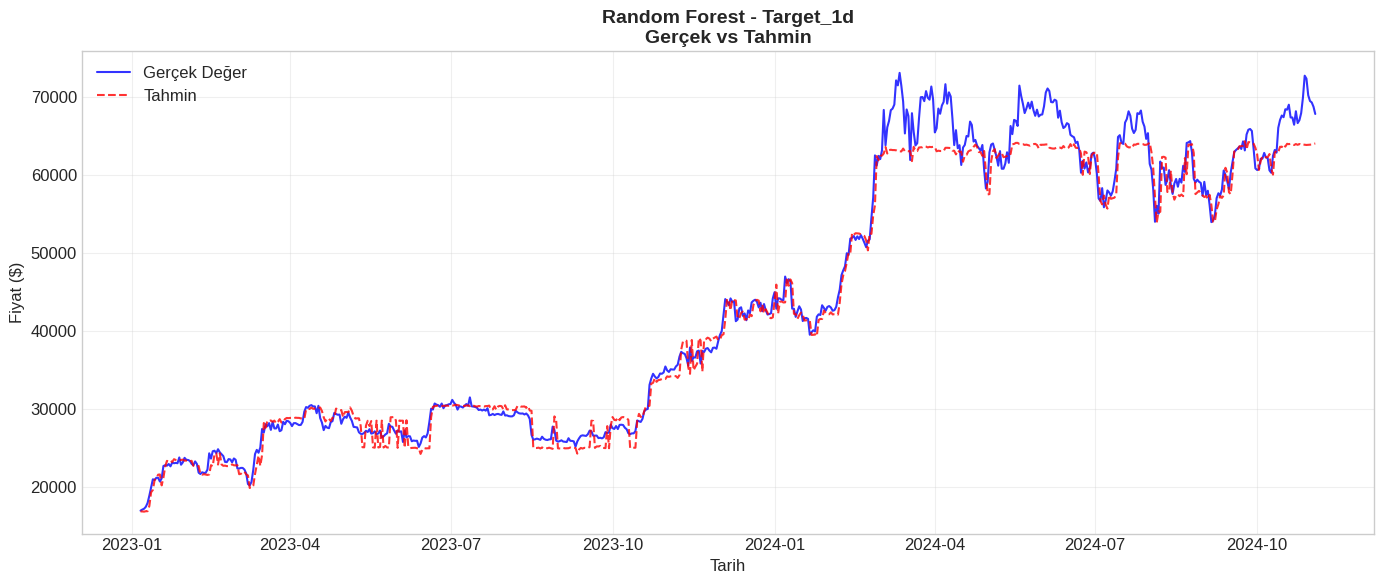

   💾 Kaydedildi: plots_advanced_ibrahim/plot_RandomForest_Target_1d.png


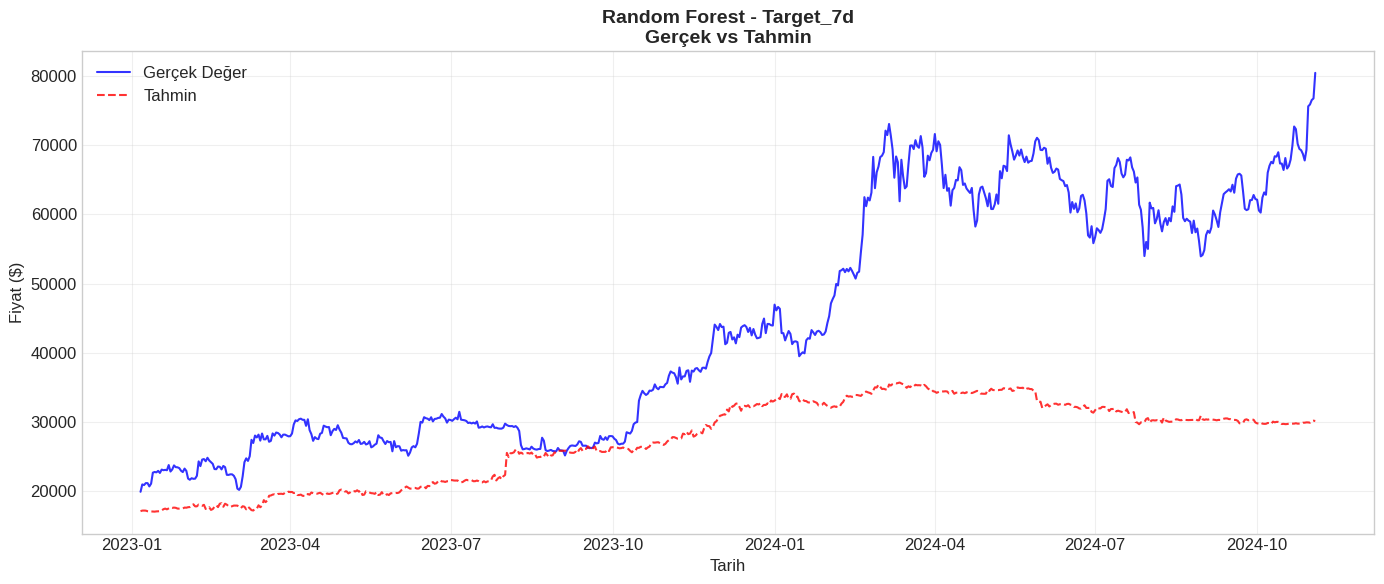

   💾 Kaydedildi: plots_advanced_ibrahim/plot_RandomForest_Target_7d.png


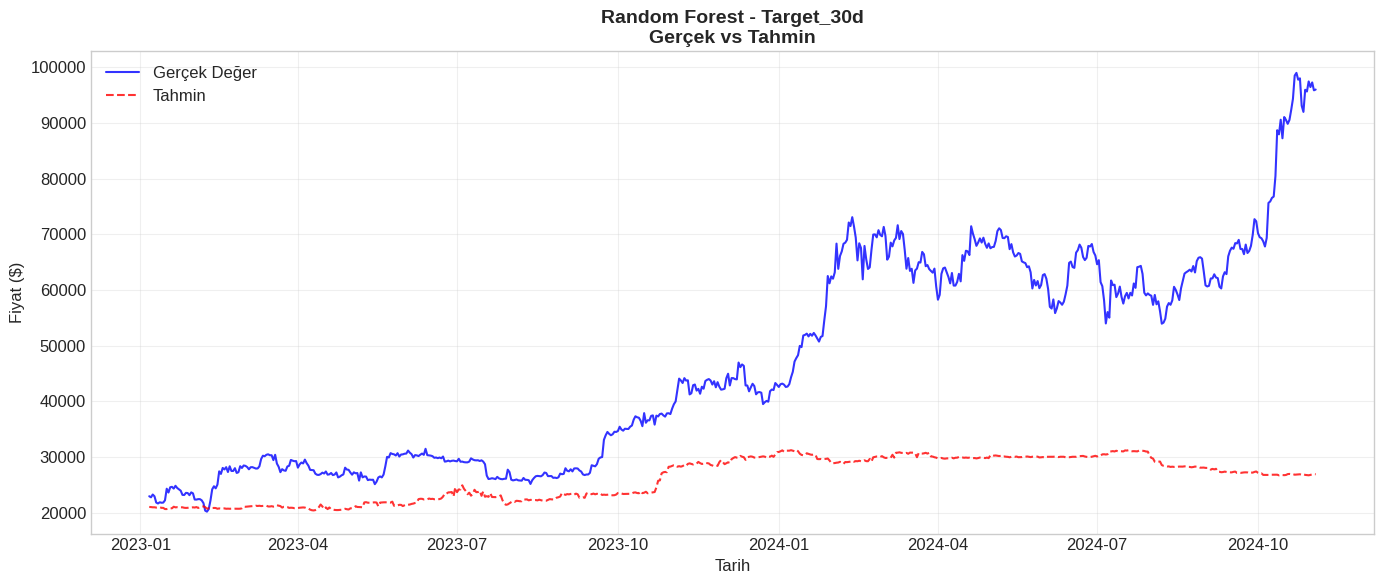

   💾 Kaydedildi: plots_advanced_ibrahim/plot_RandomForest_Target_30d.png


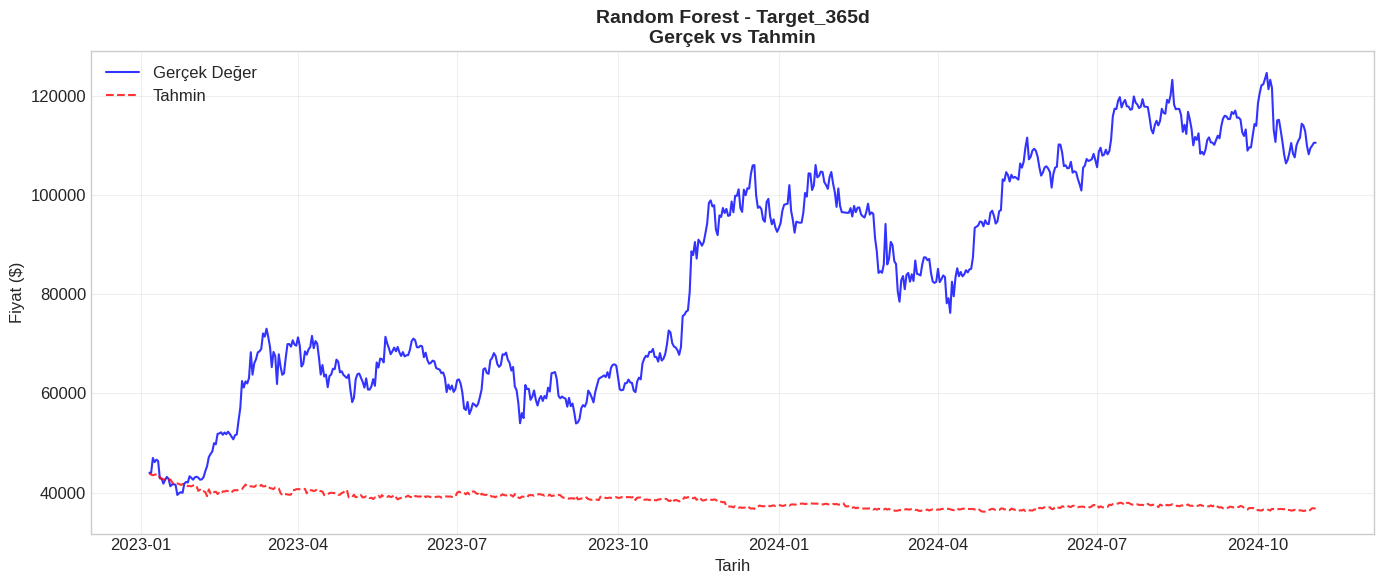

   💾 Kaydedildi: plots_advanced_ibrahim/plot_RandomForest_Target_365d.png


In [19]:
# Random Forest grafikleri
print("\n🌲 Random Forest Grafikleri:")
print("-"*40)

for target in targets:
    y_test = df[target].iloc[split_index:].values
    y_pred = rf_predictions[target]

    save_path = f'plots_advanced_ibrahim/plot_RandomForest_{target}.png'
    plot_predictions(test_dates, y_test, y_pred, 'Random Forest', target, save_path)


🧠 MLP Regressor Grafikleri:
----------------------------------------


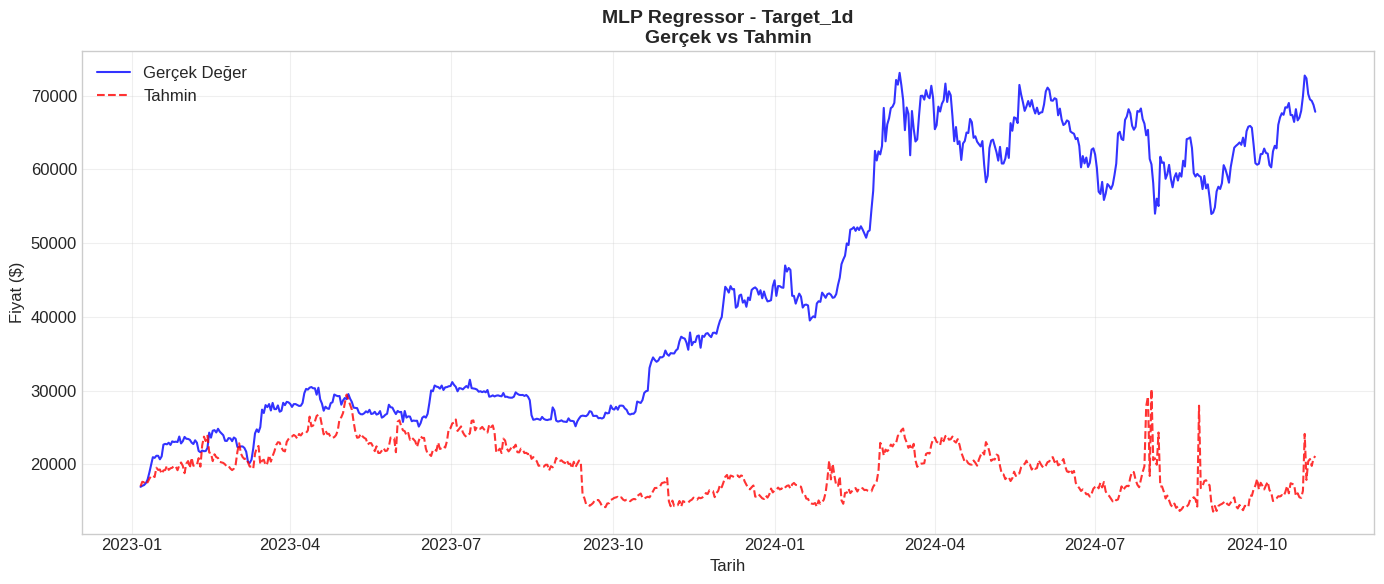

   💾 Kaydedildi: plots_advanced_ibrahim/plot_MLPRegressor_Target_1d.png


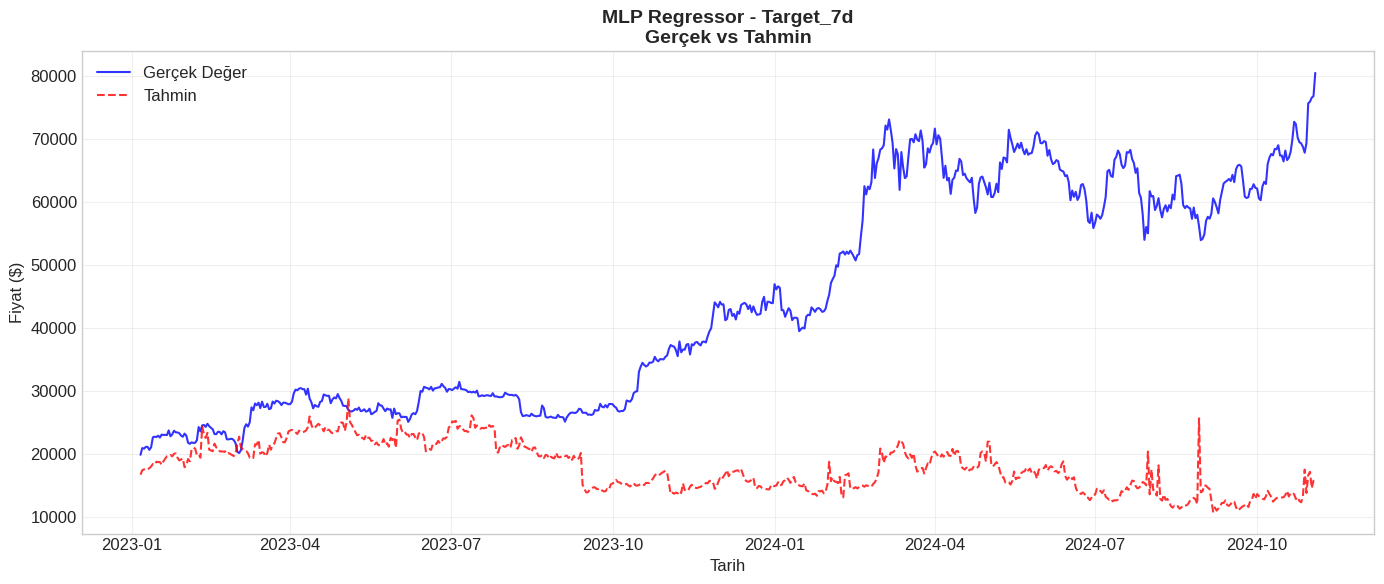

   💾 Kaydedildi: plots_advanced_ibrahim/plot_MLPRegressor_Target_7d.png


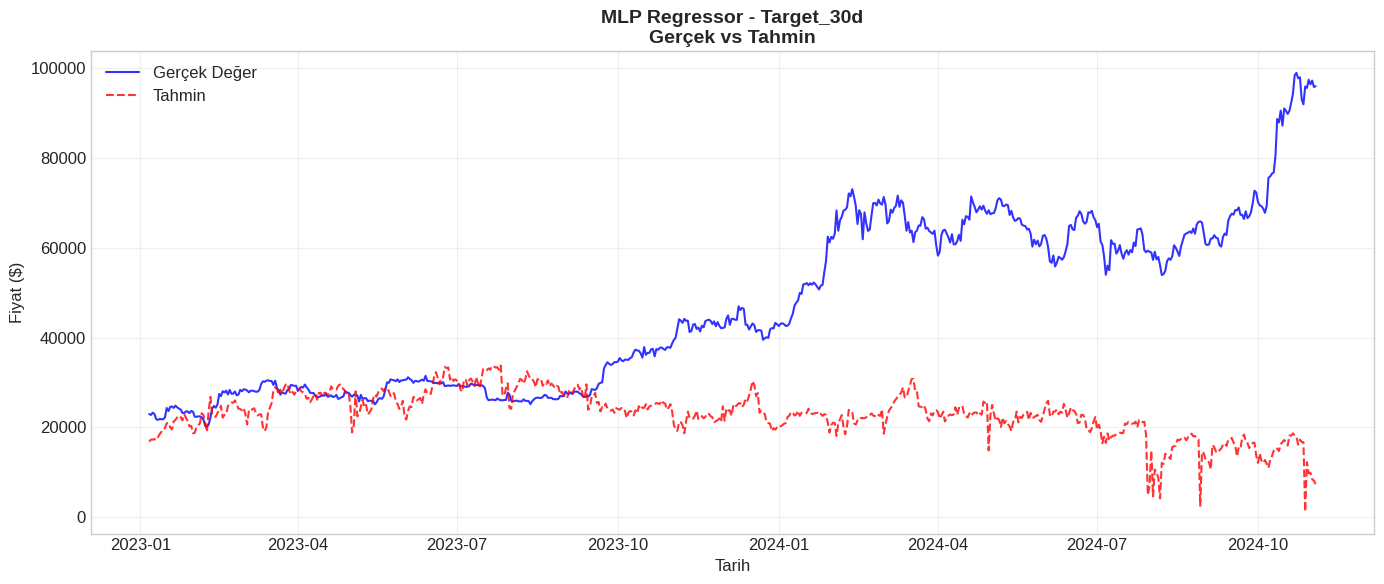

   💾 Kaydedildi: plots_advanced_ibrahim/plot_MLPRegressor_Target_30d.png


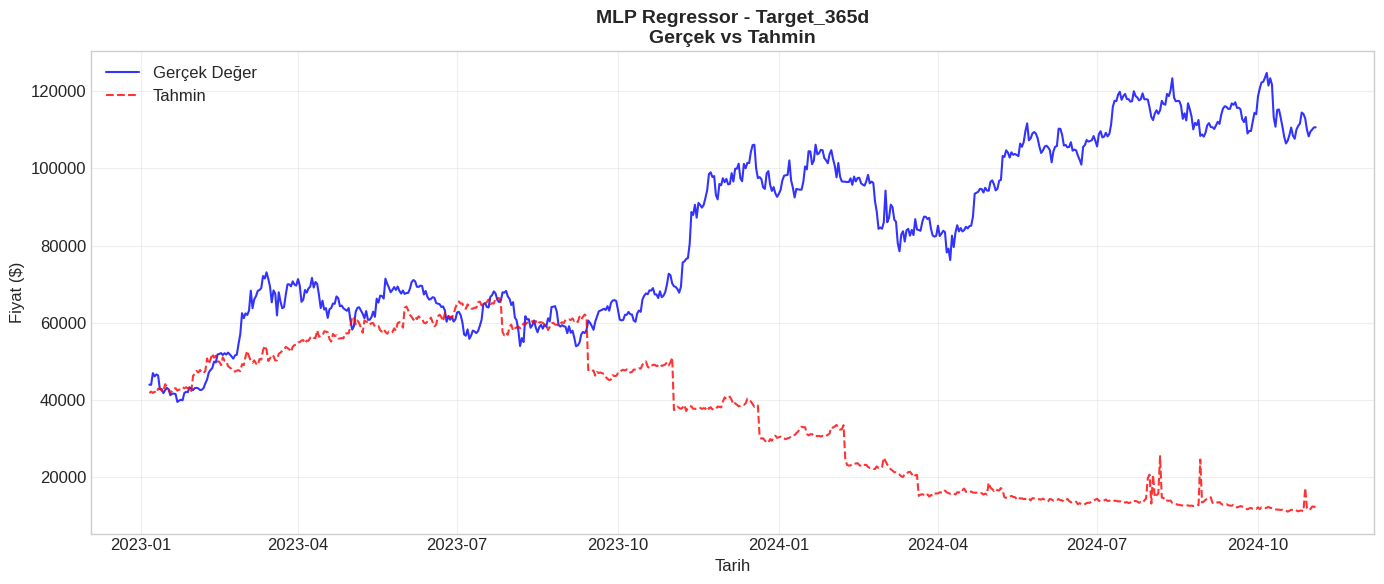

   💾 Kaydedildi: plots_advanced_ibrahim/plot_MLPRegressor_Target_365d.png


In [20]:
# MLP Regressor grafikleri
print("\n🧠 MLP Regressor Grafikleri:")
print("-"*40)

for target in targets:
    y_test = df[target].iloc[split_index:].values
    y_pred = mlp_predictions[target]

    save_path = f'plots_advanced_ibrahim/plot_MLPRegressor_{target}.png'
    plot_predictions(test_dates, y_test, y_pred, 'MLP Regressor', target, save_path)

## 🔟 Modelleri Kaydet

In [21]:
print("💾 Modelleri Kaydetme...\n")
print("="*60)

feature_list = X.columns.tolist()

# Random Forest modellerini kaydet
print("\n🌲 Random Forest Modelleri:")
for target in targets:
    model_data = {
        'model': rf_models[target],
        'features': feature_list,
        'target': target,
        'best_params': rf_best_params[target],
        'metrics': rf_results[target],
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    save_path = f'models_advanced_ibrahim/RandomForest_{target}.joblib'
    joblib.dump(model_data, save_path)
    print(f"   ✅ {save_path}")

# MLP modellerini kaydet
print("\n🧠 MLP Regressor Modelleri:")
for target in targets:
    model_data = {
        'model': mlp_models[target],
        'scaler': scaler,
        'features': feature_list,
        'target': target,
        'best_params': mlp_best_params[target],
        'metrics': mlp_results[target],
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    save_path = f'models_advanced_ibrahim/MLPRegressor_{target}.joblib'
    joblib.dump(model_data, save_path)
    print(f"   ✅ {save_path}")

print("\n" + "="*60)
print("✅ Tüm modeller başarıyla kaydedildi!")

💾 Modelleri Kaydetme...


🌲 Random Forest Modelleri:
   ✅ models_advanced_ibrahim/RandomForest_Target_1d.joblib
   ✅ models_advanced_ibrahim/RandomForest_Target_7d.joblib
   ✅ models_advanced_ibrahim/RandomForest_Target_30d.joblib
   ✅ models_advanced_ibrahim/RandomForest_Target_365d.joblib

🧠 MLP Regressor Modelleri:
   ✅ models_advanced_ibrahim/MLPRegressor_Target_1d.joblib
   ✅ models_advanced_ibrahim/MLPRegressor_Target_7d.joblib
   ✅ models_advanced_ibrahim/MLPRegressor_Target_30d.joblib
   ✅ models_advanced_ibrahim/MLPRegressor_Target_365d.joblib

✅ Tüm modeller başarıyla kaydedildi!


## 1️⃣1️⃣ Sonuçları CSV'ye Yaz

In [22]:
# Sonuçları CSV'ye kaydet
results_csv_path = 'results_advanced_ibrahim.csv'
results_df.to_csv(results_csv_path, index=False)

print(f"📄 Sonuçlar CSV'ye kaydedildi: {results_csv_path}")
print("\n" + "="*60)
print("\n📊 CSV İçeriği:")
results_df

📄 Sonuçlar CSV'ye kaydedildi: results_advanced_ibrahim.csv


📊 CSV İçeriği:


,Target,Model,RMSE,MAE,R2,MAPE_%,Num_Features,Best_Params
0,Target_1d,RandomForest,2399.469122,1664.669243,0.980813,3.620353,112,"{'n_estimators': 200, 'min_samples_split': 20,..."
1,Target_7d,RandomForest,21219.768821,16945.249211,-0.486169,33.056231,112,"{'n_estimators': 100, 'min_samples_split': 20,..."
2,Target_30d,RandomForest,26274.425132,20600.994366,-0.889766,37.200573,112,"{'n_estimators': 300, 'min_samples_split': 2, ..."
3,Target_365d,RandomForest,51131.942514,45108.188764,-4.013433,49.604895,112,"{'n_estimators': 50, 'min_samples_split': 5, '..."
4,Target_1d,MLPRegressor,30556.549193,24367.146210,-2.111641,46.818530,112,"{'max_iter': 500, 'learning_rate': 'constant',..."
5,Target_7d,MLPRegressor,32934.741342,26380.185656,-2.580103,50.287409,112,"{'max_iter': 500, 'learning_rate': 'constant',..."
6,Target_30d,MLPRegressor,32745.009119,24551.415277,-1.935160,41.900394,112,"{'max_iter': 500, 'learning_rate': 'adaptive',..."
7,Target_365d,MLPRegressor,62160.498035,48267.433800,-6.409341,49.043819,112,"{'max_iter': 500, 'learning_rate': 'adaptive',..."


## 1️⃣2️⃣ En İyi Model Seçimi

In [23]:
print("🏆 EN İYİ MODEL ANALİZİ")
print("="*60)

# Her target için en iyi modeli bul
for target in targets:
    print(f"\n🎯 {target}:")
    print("-"*40)

    target_results = results_df[results_df['Target'] == target]

    # En düşük RMSE
    best_rmse = target_results.loc[target_results['RMSE'].idxmin()]
    print(f"   📉 En Düşük RMSE: {best_rmse['Model']} (RMSE: {best_rmse['RMSE']:.4f})")

    # En yüksek R²
    best_r2 = target_results.loc[target_results['R2'].idxmax()]
    print(f"   📈 En Yüksek R²: {best_r2['Model']} (R²: {best_r2['R2']:.4f})")

🏆 EN İYİ MODEL ANALİZİ

🎯 Target_1d:
----------------------------------------
   📉 En Düşük RMSE: RandomForest (RMSE: 2399.4691)
   📈 En Yüksek R²: RandomForest (R²: 0.9808)

🎯 Target_7d:
----------------------------------------
   📉 En Düşük RMSE: RandomForest (RMSE: 21219.7688)
   📈 En Yüksek R²: RandomForest (R²: -0.4862)

🎯 Target_30d:
----------------------------------------
   📉 En Düşük RMSE: RandomForest (RMSE: 26274.4251)
   📈 En Yüksek R²: RandomForest (R²: -0.8898)

🎯 Target_365d:
----------------------------------------
   📉 En Düşük RMSE: RandomForest (RMSE: 51131.9425)
   📈 En Yüksek R²: RandomForest (R²: -4.0134)


In [24]:
# Genel en iyi modeli bul (ortalama performansa göre)
print("\n" + "="*60)
print("\n🏆 GENEL EN İYİ MODEL (Tüm Targetlar Ortalaması)")
print("-"*60)

# Model bazında ortalama metrikler
model_avg = results_df.groupby('Model').agg({
    'RMSE': 'mean',
    'MAE': 'mean',
    'R2': 'mean',
    'MAPE_%': 'mean'
}).round(4)

print("\n📊 Model Bazında Ortalama Metrikler:")
print(model_avg)

# En iyi model (en yüksek ortalama R²)
best_model = model_avg['R2'].idxmax()
print(f"\n🥇 Genel En İyi Model: {best_model}")
print(f"   - Ortalama RMSE: {model_avg.loc[best_model, 'RMSE']:.4f}")
print(f"   - Ortalama MAE: {model_avg.loc[best_model, 'MAE']:.4f}")
print(f"   - Ortalama R²: {model_avg.loc[best_model, 'R2']:.4f}")
print(f"   - Ortalama MAPE: {model_avg.loc[best_model, 'MAPE_%']:.2f}%")
print(f"   - Tuning Yöntemi: RandomizedSearchCV with TimeSeriesSplit")



🏆 GENEL EN İYİ MODEL (Tüm Targetlar Ortalaması)
------------------------------------------------------------

📊 Model Bazında Ortalama Metrikler:
                    RMSE         MAE      R2   MAPE_%
Model                                                
MLPRegressor  39599.1994  30891.5452 -3.2591  47.0125
RandomForest  25256.4014  21079.7754 -1.1021  30.8705

🥇 Genel En İyi Model: RandomForest
   - Ortalama RMSE: 25256.4014
   - Ortalama MAE: 21079.7754
   - Ortalama R²: -1.1021
   - Ortalama MAPE: 30.87%
   - Tuning Yöntemi: RandomizedSearchCV with TimeSeriesSplit


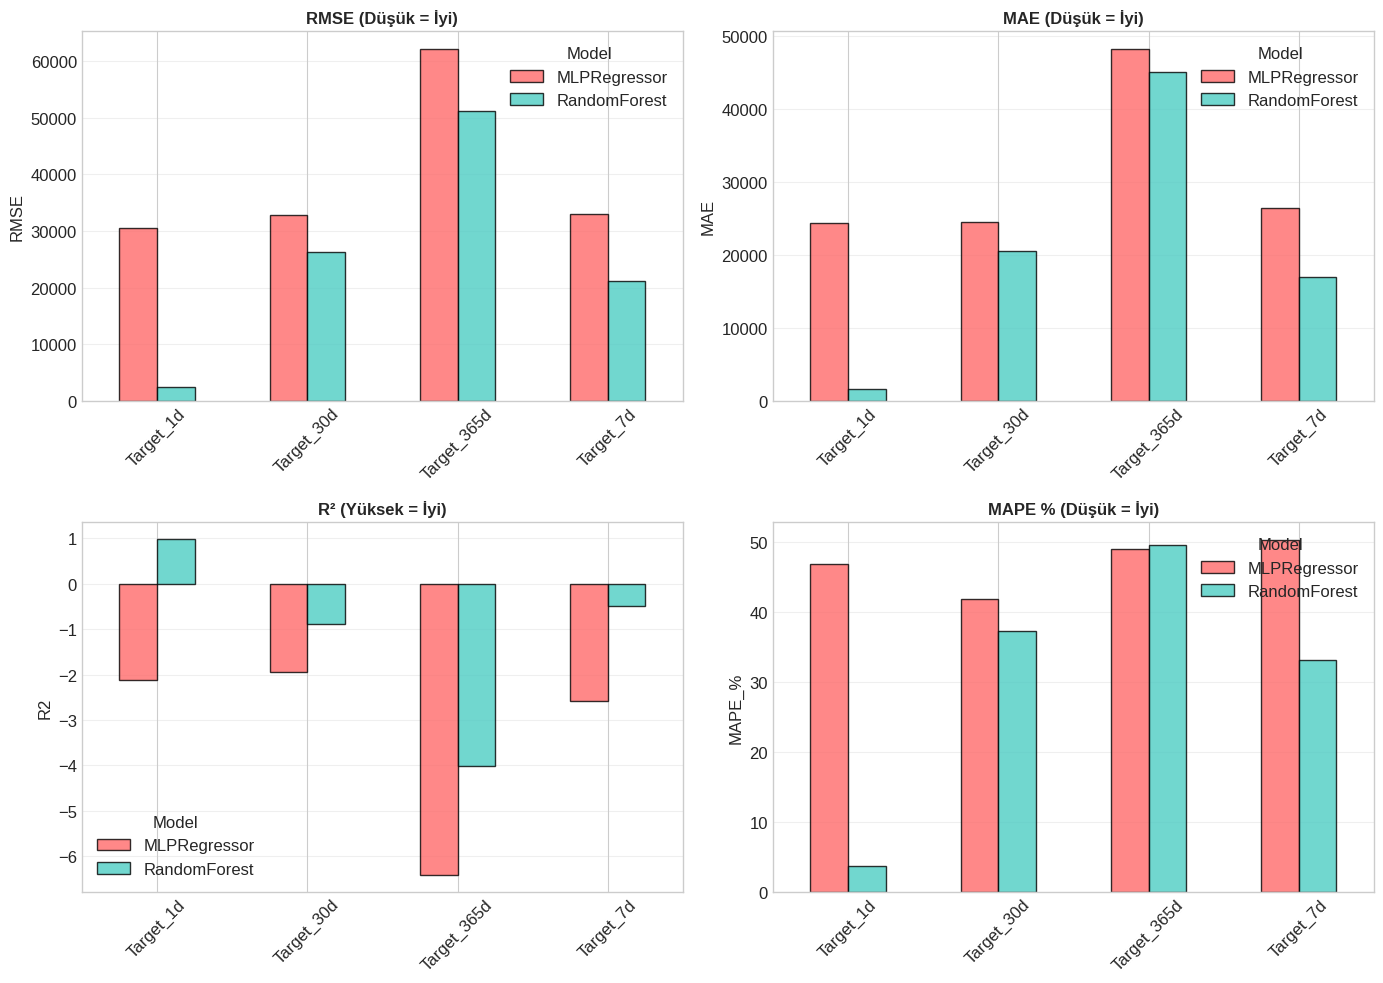

💾 Karşılaştırma grafiği kaydedildi: plots_advanced_ibrahim/model_comparison.png


In [25]:
# Karşılaştırma grafiği
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['RMSE', 'MAE', 'R2', 'MAPE_%']
titles = ['RMSE (Düşük = İyi)', 'MAE (Düşük = İyi)', 'R² (Yüksek = İyi)', 'MAPE % (Düşük = İyi)']
colors = ['#FF6B6B', '#4ECDC4']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]

    pivot_data = results_df.pivot(index='Target', columns='Model', values=metric)
    pivot_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.legend(title='Model')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots_advanced_ibrahim/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Karşılaştırma grafiği kaydedildi: plots_advanced_ibrahim/model_comparison.png")

## 📝 Özet ve Sonuç

In [26]:
print("\n" + "="*60)
print("📋 PROJE ÖZETİ")
print("="*60)

print(f"""
📚 Dataset Bilgileri:
   - Kaynak: data/merged_with_lags.csv
   - Toplam Satır: {len(df):,}
   - Feature Sayısı: {len(X.columns)}
   - Tarih Aralığı: {df['Date'].min().date()} → {df['Date'].max().date()}

🎯 Target Değişkenler:
   - Target_1d (1 Günlük)
   - Target_7d (7 Günlük)
   - Target_30d (30 Günlük)
   - Target_365d (365 Günlük)

📊 Veri Bölümü (Zaman Serisi Split):
   - Train: {split_index:,} satır ({split_ratio*100:.0f}%)
   - Test: {len(df) - split_index:,} satır ({(1-split_ratio)*100:.0f}%)

🤖 Kullanılan Modeller:
   1. Random Forest Regressor (RandomizedSearchCV ile tuning)
   2. MLP Regressor (RandomizedSearchCV ile tuning)

📁 Oluşturulan Dosyalar:
   - plots_advanced_ibrahim/ (8 grafik)
   - models_advanced_ibrahim/ (8 model dosyası)
   - results_advanced_ibrahim.csv

🏆 En İyi Model: {best_model}
   - Ortalama R²: {model_avg.loc[best_model, 'R2']:.4f}
""")

print("="*60)
print("✅ PROJE TAMAMLANDI!")
print("="*60)


📋 PROJE ÖZETİ

📚 Dataset Bilgileri:
   - Kaynak: data/merged_with_lags.csv
   - Toplam Satır: 3,338
   - Feature Sayısı: 112
   - Tarih Aralığı: 2015-09-15 → 2024-11-03

🎯 Target Değişkenler:
   - Target_1d (1 Günlük)
   - Target_7d (7 Günlük)
   - Target_30d (30 Günlük)
   - Target_365d (365 Günlük)

📊 Veri Bölümü (Zaman Serisi Split):
   - Train: 2,670 satır (80%)
   - Test: 668 satır (20%)

🤖 Kullanılan Modeller:
   1. Random Forest Regressor (RandomizedSearchCV ile tuning)
   2. MLP Regressor (RandomizedSearchCV ile tuning)

📁 Oluşturulan Dosyalar:
   - plots_advanced_ibrahim/ (8 grafik)
   - models_advanced_ibrahim/ (8 model dosyası)
   - results_advanced_ibrahim.csv

🏆 En İyi Model: RandomForest
   - Ortalama R²: -1.1021

✅ PROJE TAMAMLANDI!
